# 🏈 Modeling Real Daily Events (Peyton Manning Data)

## 1. Why Daily Data is Better
When we used monthly data, we had to assume a "Summer Peak" lasted for 3 months. With daily data, we can be surgically precise.
* **Exact Match:** We can say "The Super Bowl happened on Feb 7, 2016" and Prophet will look for a spike on *that exact day*.
* **Windows:** We can model the "hype" building up to the event (e.g., 3 days before) and the "cooldown" (1 day after) using `lower_window` and `upper_window`.

## 2. The Dataset
We are using the **Log Daily Page Views** for the Wikipedia page of Peyton Manning (an American Football quarterback).
* **Pattern:** He has a regular yearly cycle (football season).
* **The Shock:** He plays in the **Super Bowl** and **Playoffs** on specific dates. These are our "Special Events."

## 3. The Goal
We want Prophet to learn:
1.  The general trend of his popularity.
2.  The weekly pattern (do people read about him more on Mondays?).
3.  The **Specific Impact** of reaching the Playoffs or the Super Bowl.

#### 1) Importing Necessary Libraries:

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.utilities import regressor_coefficients

#### 2) Loading Data:

In [2]:
url = 'https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


In [4]:
df.shape

(2905, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      2905 non-null   object 
 1   y       2905 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.5+ KB


In [6]:
df.describe()

,y
count,2905.000000
mean,8.138958
std,0.845957
min,5.262690
25%,7.514800
50%,7.997999
75%,8.580168
max,12.846747


##### Visualizing Data:

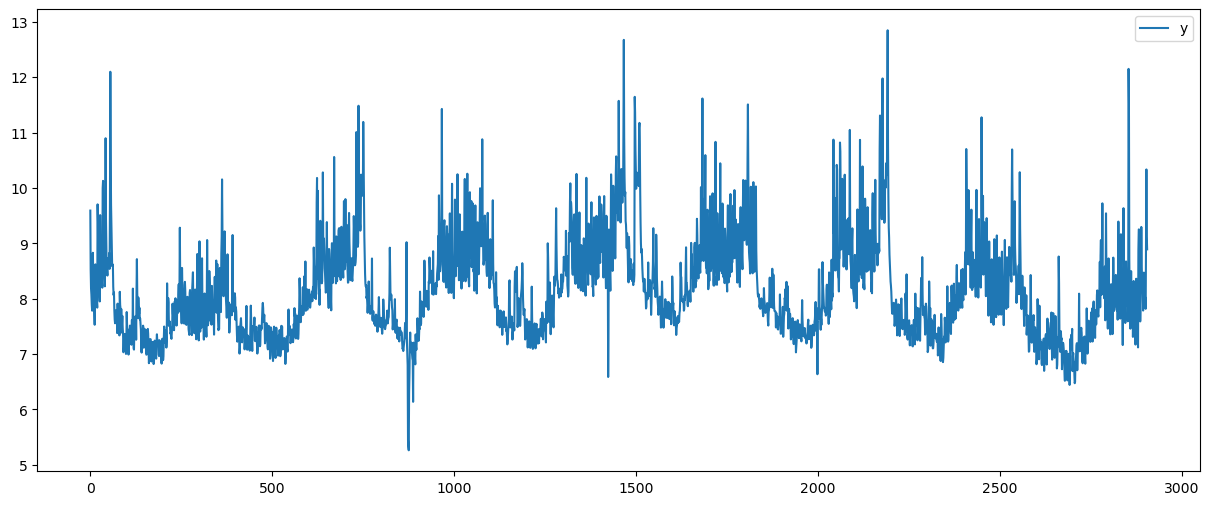

In [7]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) Creating Special Events DataFrame:

##### Event 1: Super Bowls

In [8]:
superbowls = pd.DataFrame({
    'holiday': 'superbowl',
    'ds': pd.to_datetime(['2010-02-07', '2014-02-02', '2016-02-07']),
    'lower_window': 0,
    'upper_window': 1
})

In [9]:
superbowls

,holiday,ds,lower_window,upper_window
0,superbowl,2010-02-07,0,1
1,superbowl,2014-02-02,0,1
2,superbowl,2016-02-07,0,1


##### Event 2: Playoffs

In [10]:
playoffs = pd.DataFrame({
    'holiday': 'playoff',
    'ds': pd.to_datetime([
        '2008-01-13', '2009-01-03', '2010-01-16', '2010-01-24', 
        '2010-12-26', '2012-01-08', '2013-01-12', '2014-01-12', 
        '2014-01-19', '2015-01-11', '2016-01-17', '2016-01-24'
    ]),
    'lower_window': 0,
    'upper_window': 1
})

In [11]:
playoffs

,holiday,ds,lower_window,upper_window
0,playoff,2008-01-13,0,1
1,playoff,2009-01-03,0,1
2,playoff,2010-01-16,0,1
3,playoff,2010-01-24,0,1
4,playoff,2010-12-26,0,1
5,playoff,2012-01-08,0,1
6,playoff,2013-01-12,0,1
7,playoff,2014-01-12,0,1
8,playoff,2014-01-19,0,1
9,playoff,2015-01-11,0,1


##### Combining into One Holiday Dataframe:

In [12]:
holidays = pd.concat((superbowls, playoffs))

In [13]:
holidays

,holiday,ds,lower_window,upper_window
0,superbowl,2010-02-07,0,1
1,superbowl,2014-02-02,0,1
2,superbowl,2016-02-07,0,1
0,playoff,2008-01-13,0,1
1,playoff,2009-01-03,0,1
2,playoff,2010-01-16,0,1
3,playoff,2010-01-24,0,1
4,playoff,2010-12-26,0,1
5,playoff,2012-01-08,0,1
6,playoff,2013-01-12,0,1


#### 4) Model:

In [14]:
model = Prophet(holidays= holidays,
               daily_seasonality= False,
               weekly_seasonality= True) #very important for web traffic

model.fit(df)

18:19:10 - cmdstanpy - INFO - Chain [1] start processing
18:19:11 - cmdstanpy - INFO - Chain [1] done processing


##### Forecast:

In [15]:
future_df = model.make_future_dataframe(periods= 365)
future_df.head()

,ds
0,2007-12-10
1,2007-12-11
2,2007-12-12
3,2007-12-13
4,2007-12-14


In [16]:
forecast = model.predict(future_df)

In [17]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.064935,8.267617,9.483902,8.064935,8.064935,0.792186,0.792186,0.792186,0.0,...,0.326713,0.326713,0.326713,0.465473,0.465473,0.465473,0.0,0.0,0.0,8.857121
1,2007-12-11,8.063227,8.044907,9.243879,8.063227,8.063227,0.581663,0.581663,0.581663,0.0,...,0.132302,0.132302,0.132302,0.449361,0.449361,0.449361,0.0,0.0,0.0,8.644890
2,2007-12-12,8.061519,7.851436,9.054611,8.061519,8.061519,0.380055,0.380055,0.380055,0.0,...,-0.053968,-0.053968,-0.053968,0.434024,0.434024,0.434024,0.0,0.0,0.0,8.441575
3,2007-12-13,8.059812,7.825219,9.000093,8.059812,8.059812,0.360005,0.360005,0.360005,0.0,...,-0.059836,-0.059836,-0.059836,0.419841,0.419841,0.419841,0.0,0.0,0.0,8.419816
4,2007-12-14,8.058104,7.821733,8.991784,8.058104,8.058104,0.350146,0.350146,0.350146,0.0,...,-0.057011,-0.057011,-0.057011,0.407158,0.407158,0.407158,0.0,0.0,0.0,8.408250


In [18]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3265,2017-01-15,7.197673,7.303650,8.752681,6.865135,7.582833,0.862119,0.862119,0.862119,0.0,...,0.019141,0.019141,0.019141,0.842979,0.842979,0.842979,0.0,0.0,0.0,8.059793
3266,2017-01-16,7.196680,7.681028,9.070328,6.861446,7.583384,1.192406,1.192406,1.192406,0.0,...,0.326713,0.326713,0.326713,0.865693,0.865693,0.865693,0.0,0.0,0.0,8.389086
3267,2017-01-17,7.195686,7.498081,8.919605,6.858178,7.583935,1.020519,1.020519,1.020519,0.0,...,0.132302,0.132302,0.132302,0.888217,0.888217,0.888217,0.0,0.0,0.0,8.216205
3268,2017-01-18,7.194692,7.381867,8.757781,6.854914,7.584359,0.856341,0.856341,0.856341,0.0,...,-0.053968,-0.053968,-0.053968,0.910309,0.910309,0.910309,0.0,0.0,0.0,8.051033
3269,2017-01-19,7.193699,7.372462,8.794855,6.852059,7.584694,0.871841,0.871841,0.871841,0.0,...,-0.059836,-0.059836,-0.059836,0.931677,0.931677,0.931677,0.0,0.0,0.0,8.065540


In [19]:
forecast.shape

(3270, 28)

##### Visualizing Forecast:

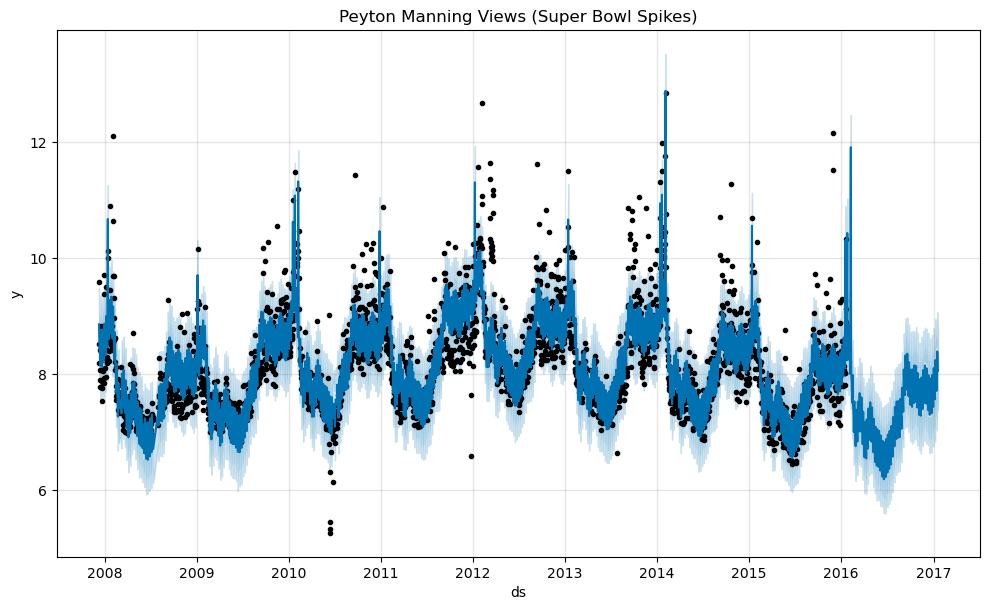

In [20]:
fig1 = model.plot(forecast)
plt.title('Peyton Manning Views (Super Bowl Spikes)')
plt.show()

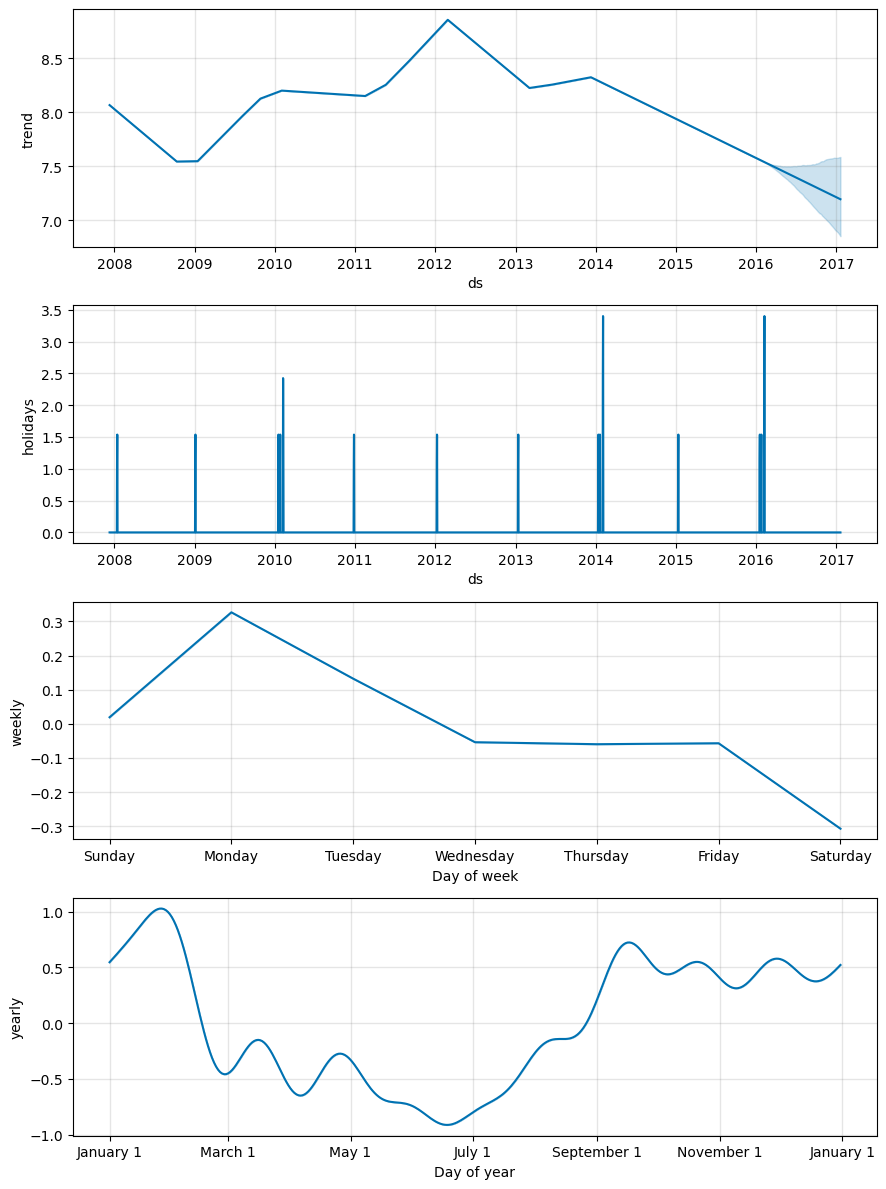

In [22]:
fig2 = model.plot_components(forecast)
plt.show()